<a href="https://colab.research.google.com/github/AYMAN-CHAREF/machine-learning-et-deep-learning/blob/main/Impl%C3%A9mentation_%C3%A0_partir_de_z%C3%A9ro_de_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np

#**1.Création et visualisation de la BD**


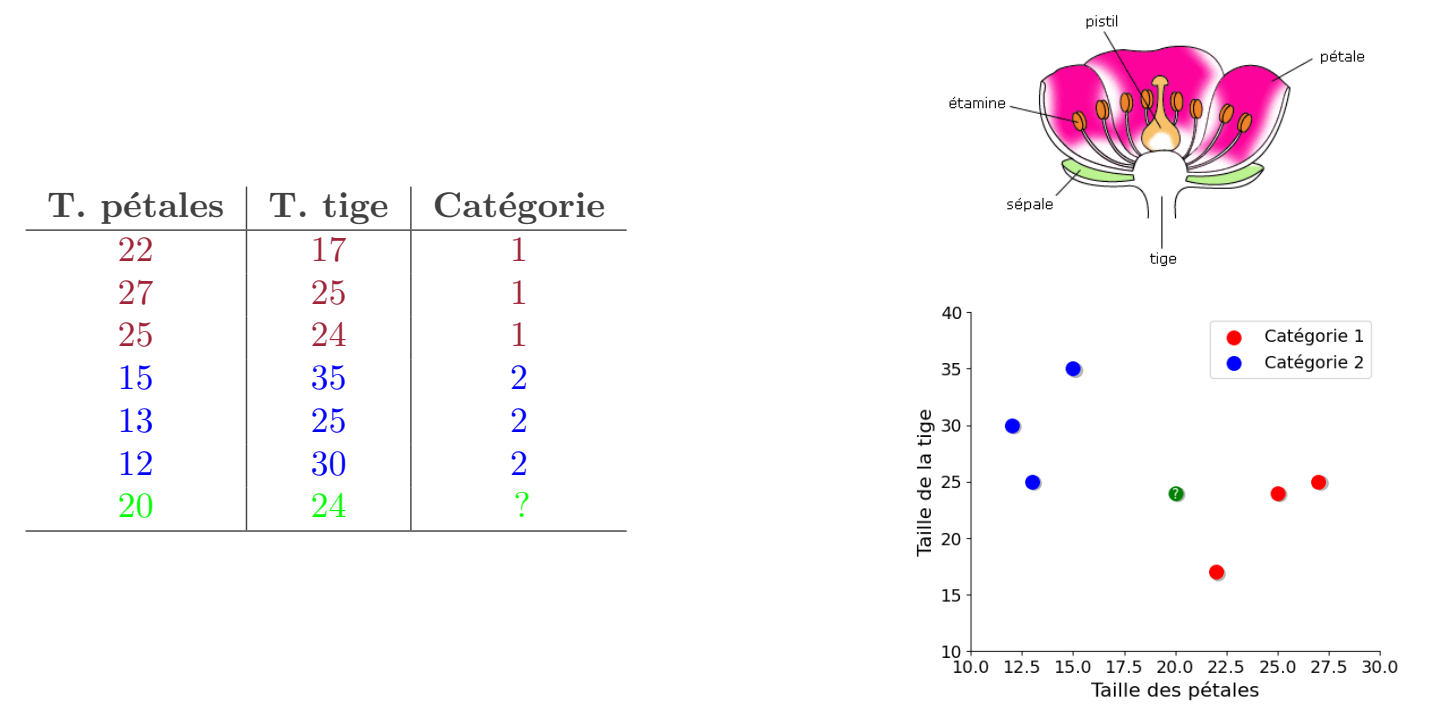

In [2]:
# Données du tableau
data = np.array([
    [22, 17, 1],
    [27, 25, 1],
    [25, 24, 1],
    [15, 35, 2],
    [13, 25, 2],
    [12, 30, 2],
    [20, 24, -1]
])

In [3]:
# Séparation des colonnes
x = data[:, 0]  # Première colonne
y = data[:, 1]  # Deuxième colonne
categories = data[:, 2]  # Troisième colonne (catégorie)

In [4]:
# Séparation des colonnes
X = data[:, 0:2]#Caractéristiques
Y = data[:, 2]  # catégorie


X.shape,Y.shape

((7, 2), (7,))

In [5]:
def visualisationBD(X,Y):

  # Création du nuage de points
  plt.figure(figsize=(7, 7))

  # Parcourir les catégories pour attribuer des couleurs et des formes
  for i, category in enumerate(Y):
    if category == 1:

        plt.scatter(X[i,0], X[i,1], c='red', marker='o',s=125, label='Catégorie 1' if i == 0 else "")
    elif category == 2:

        plt.scatter(X[i,0], X[i,1], c='blue', marker='o',s=125, label='Catégorie 2' if i == 3 else "")
    else:

      plt.scatter(X[i,0], X[i,1], c='green', marker='o', s=125,  label='Nouvelle observation')

      plt.text(X[i,0] + 0.01, X[i,1] - 0.1, '?', fontsize=11, ha='center', va='center', color='white')


  # Ajout des labels et de la légende
  plt.xlabel('Taille des pétales',fontsize=16)
  plt.ylabel('Taille de la tige',fontsize=16)
  plt.legend(fontsize=14)

  plt.xticks(fontsize=14)
  plt.yticks(fontsize=14)

  plt.xlim([10, 30])
  plt.ylim([10, 40])

  plt.gca().spines['top'].set_visible(False)
  plt.gca().spines['right'].set_visible(False)



  plt.show()

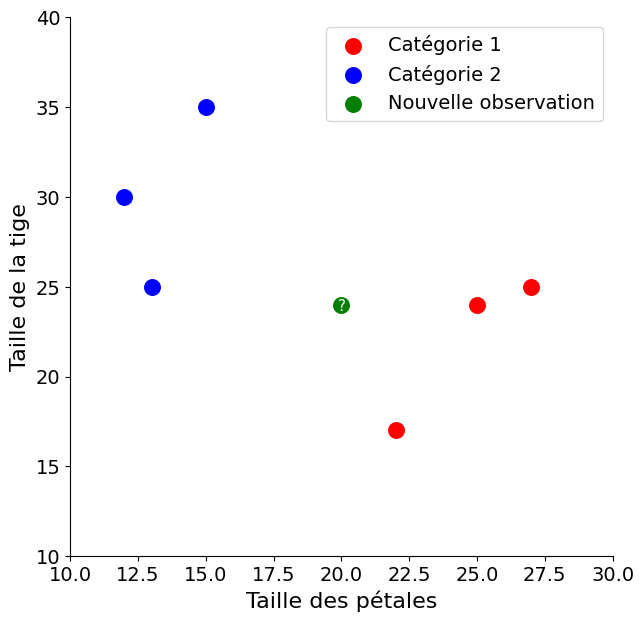

In [6]:
visualisationBD(X,Y)

#**2. Implémenation de KNN from Scratch**

In [10]:
#Implémentation de l’algorithme e KNN à partir de Zéro
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from collections import Counter

def algo_knn(E, x_test, k, task='classification'):
  # Calcul des distances (Euclidienne)
    distances = np.sqrt(np.sum((E['X'] - x_test) ** 2, axis=1))

    # Sélection des k plus proches voisins
    k_indices = np.argsort(distances)[:k]
    k_nearest_labels = E['Y'][k_indices]

    if task == 'classification':

      return Counter(k_nearest_labels).most_common(1)[0][0], k_indices
    else:# task == 'regression':
        # Retourner la moyenne des valeurs
        return np.mean(k_nearest_labels), k_indices

# **3.Classification de la nouvelle observation**
## **3.1 Classification de la nouvelle observation pour k=3**

In [11]:
n=len(X)
X_train=X[0:n-1]
y_train=Y[0:n-1]
X_test=X[-1]
y_test=Y[-1]


E={"X":X_train,"Y":y_train}
k=3
t="Classification"
x=X_test


In [12]:
y_pred,Kpv=algo_knn(E,x,k,task="classification")

In [13]:
print( "la classe de l'observation ",x, " est ",y_pred)

la classe de l'observation  [20 24]  est  1


## **3.2 Classification et visualisation de la nouvelle observation pour k=5**

In [14]:
def visualisationBD(E,x,y_pred,Kpv):

  # Création du nuage de points
  plt.figure(figsize=(7, 8))

  # Parcourir les catégories pour attribuer des couleurs et des formes
  colorsCat=['red','blue']
  for i, category in enumerate(E['Y']):
    if category == 1:

        plt.scatter(E['X'][i,0], E['X'][i,1], c='red', marker='o',s=50, label='Catégorie 1' if i == 0 else "")

    elif category == 2:

        plt.scatter(E['X'][i,0], E['X'][i,1], c='blue', marker='o',s=50, label='Catégorie 2' if i == 3 else "")

    plt.text(E['X'][i,0] + 0.01, E['X'][i,1] - 2., 'O'+str(i), fontsize=11, ha='center', va='center', color='k')


  plt.scatter(x[0], x[1], c='green', marker='o', s=125,  label='Nouvelle observation')

  plt.text(x[0] + 0.01, x[1] - 0.1, '?', fontsize=11, ha='center', va='center', color='white')

  for i in range(len( Kpv)):
    voisin=Kpv[i]
    plt.plot((x[0],E['X'][voisin,0]),(x[1],E['X'][voisin,1]), c='gray', linestyle='--')
    plt.scatter(E['X'][voisin,0], E['X'][voisin,1], c='orange', marker='o',s=300, label=str(len(Kpv))+" plus proche voisins" if i == 0 else "", alpha=0.3)


  # Ajout des labels et de la légende
  plt.xlabel('Taille des pétales',fontsize=12)
  plt.ylabel('Taille de la tige',fontsize=12)
  plt.legend(fontsize=14)

  plt.xticks(fontsize=14)
  plt.yticks(fontsize=14)

  plt.xlim([10, 30])
  plt.ylim([10, 40])

  plt.title("Classification pour K="+str(len(Kpv)),fontsize=16)

  plt.gca().spines['top'].set_visible(False)
  plt.gca().spines['right'].set_visible(False)



  plt.show()

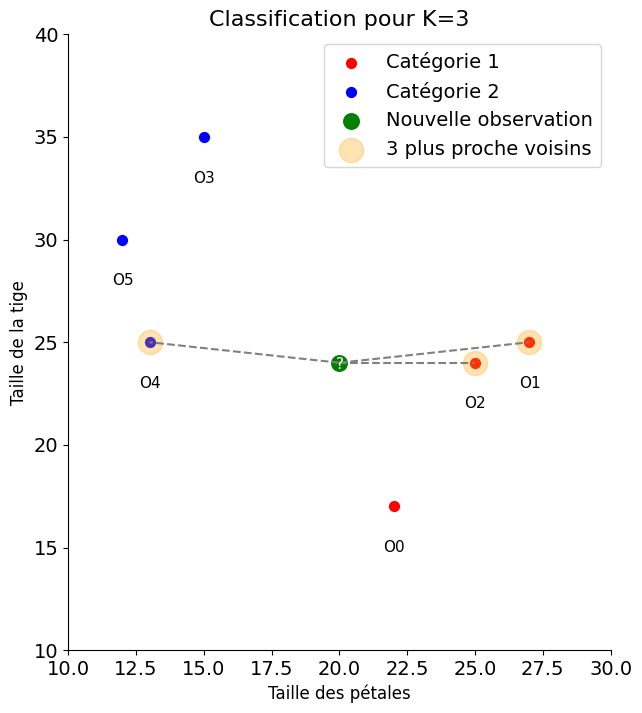

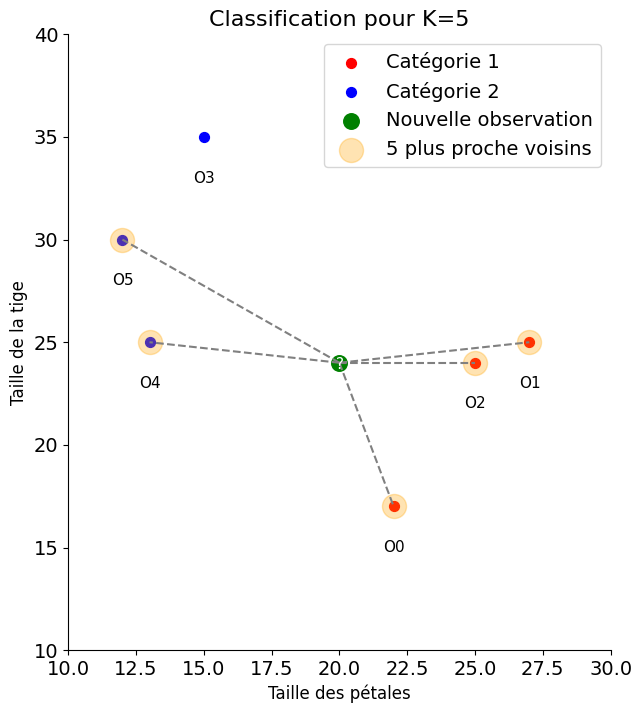

In [15]:
y_pred,Kpv=algo_knn(E,x,k=3,task="classification")
visualisationBD(E,x,y_pred,Kpv)

y_pred,Kpv=algo_knn(E,x,k=5,task="classification")
visualisationBD(E,x,y_pred,Kpv)